# 1.1 Стохастический градиентный спуск

Вариант 3: SGD с Mini-batch
Реализуйте SGD с мини-батчами размером 10. 

Сгенерируйте 100 точек данных: 
$$
y = 3 \cdot x + 1 + \varepsilon.
$$

Начальные веса: w=10, b=10. Скорость обучения 0.02. 

Сравните траекторию с обычным SGD.

Требуется:

1. Сгенерировать данные согласно описанию
2. Реализовать указанную модификацию SGD
3. Обучить модель, вывести финальные параметры
4. Построить график сходимости


```py
import numpy as np
import matplotlib.pyplot as plt

# Ваш код здесь
# ...

print(f"Финальные параметры: w = {w:.4f}, b = {b:.4f}")
print(f"Финальный loss: {loss:.6f}")
```

SGD (batch=1):  w = 2.9249, b = 1.2307, loss = 1.035255
Mini-batch=10: w = 2.9491,  b = 1.2009,  loss = 1.009486


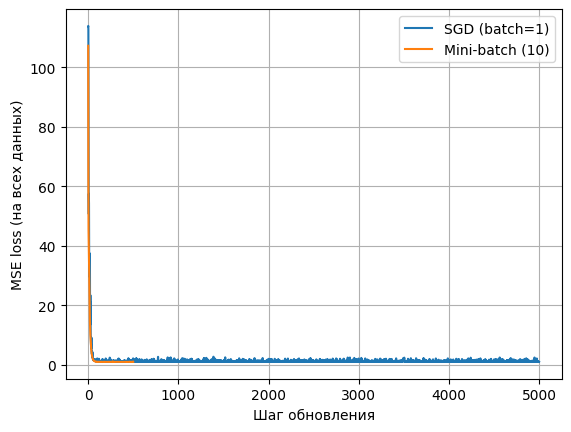

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# 1) Данные: y = 3x + 1 + eps
n = 100
x = np.random.uniform(-5, 5, n)
eps = np.random.normal(0, 1, n)
y = 3 * x + 1 + eps

lr = 0.02
epochs = 50

def mse(w, b):
    return np.mean((w * x + b - y) ** 2)

def train(batch_size):
    w, b = 10.0, 10.0
    losses = []

    for _ in range(epochs):
        idx = np.random.permutation(n)
        for i in range(0, n, batch_size):
            batch = idx[i:i + batch_size]
            xb, yb = x[batch], y[batch]

            # предсказание и ошибка
            err = (w * xb + b) - yb

            # градиенты MSE
            dw = 2 * np.mean(err * xb)
            db = 2 * np.mean(err)

            # шаг градиентного спуска
            w -= lr * dw
            b -= lr * db

            # для сравнения считаем loss на ВСЕХ данных
            losses.append(mse(w, b))

    return w, b, losses

# 2) Обучение
w_sgd, b_sgd, loss_sgd = train(batch_size=1)
w_mb,  b_mb,  loss_mb  = train(batch_size=10)

# 3) Вывод
print(f"SGD (batch=1):  w = {w_sgd:.4f}, b = {b_sgd:.4f}, loss = {loss_sgd[-1]:.6f}")
print(f"Mini-batch=10: w = {w_mb:.4f},  b = {b_mb:.4f},  loss = {loss_mb[-1]:.6f}")

# 4) График сходимости
plt.plot(loss_sgd, label="SGD (batch=1)")
plt.plot(loss_mb,  label="Mini-batch (10)")
plt.xlabel("Шаг обновления")
plt.ylabel("MSE loss (на всех данных)")
plt.legend()
plt.grid(True)
plt.show()

# 1.2 Однослойный и многослойный персептрон

Вариант 5. Персептрон для классификации ирисов (2 класса)

Загрузите датасет ирисов (sklearn.datasets.load_iris()). Возьмите только два класса (setosa и versicolor) и два признака (длина и ширина чашелистика). Обучите персептрон. Выведите веса и точность.

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data[:, :2]          # длина и ширина чашелистика
y = iris.target

# берем только setosa и versicolor
mask = y < 2
X, y = X[mask], y[mask]

model = Perceptron(max_iter=1000, eta0=0.1, random_state=0)
model.fit(X, y)

y_pred = model.predict(X)

print("Веса:", model.coef_)
print("Смещение:", model.intercept_)
print("Точность:", accuracy_score(y, y_pred))

X shape: (150, 4)
y shape: (150,)
Веса: [[ 2.32 -3.87]]
Смещение: [-0.5]
Точность: 0.99


# 1.3 Рекомендательные системы

Вариант 1. Базовая user-item матрица
Реализуйте функцию create_user_item_matrix(n_users, n_items, interactions), которая создает матрицу взаимодействий пользователь-товар. На вход подается список взаимодействий в формате [(user_id, item_id, rating), ...]. Матрица должна иметь размер n_users x n_items, где на пересечении user_id и item_id стоит рейтинг, иначе 0. Выведите полученную матрицу для 5 пользователей и 5 товаров со случайными взаимодействиями.

In [4]:
import numpy as np
import random

def create_user_item_matrix(n_users, n_items, interactions):
    matrix = np.zeros((n_users, n_items))
    for user_id, item_id, rating in interactions:
        matrix[user_id][item_id] = rating
    return matrix



n_users, n_items = 5, 5
interactions = []
for _ in range(8): 
    u = random.randint(0, n_users - 1)
    i = random.randint(0, n_items - 1)
    r = random.randint(1, 5)
    interactions.append((u, i, r))

print("Взаимодействия:", interactions)

matrix = create_user_item_matrix(n_users, n_items, interactions)

print("\nUser-Item матрица:")
print(matrix)

Взаимодействия: [(4, 0, 5), (2, 0, 1), (1, 2, 5), (2, 2, 4), (0, 2, 3), (3, 0, 4), (3, 0, 2), (1, 3, 3)]

User-Item матрица:
[[0. 0. 3. 0. 0.]
 [0. 0. 5. 3. 0.]
 [1. 0. 4. 0. 0.]
 [2. 0. 0. 0. 0.]
 [5. 0. 0. 0. 0.]]


# 1.5 Трансформеры. NLP

Вариант 4. Фильм: "Темный рыцарь" (The Dark Knight)
Используя предобученную модель для поиска ответов на вопросы (question-answering), извлеките информацию из краткого описания фильма. Для каждого вопроса программа должна найти фрагмент текста, содержащий ответ.

Модель: electra-base-squad2.

Вопросы: Кто злодей в фильме? Кто играет Бэтмена?

In [ ]:
from transformers import pipeline

context = """
The Dark Knight is a 2008 superhero film directed by Christopher Nolan.
Batman is played by Christian Bale. In Gotham City, Batman faces a criminal mastermind known as the Joker,
who plunges the city into chaos.
""".strip()

qa = pipeline("question-answering", model="deepset/electra-base-squad2")

questions = [
    "Who is the villain in the film?",
    "Who plays Batman?"
]

for q in questions:
    res = qa(question=q, context=context)
    print(f"Q: {q}")
    print(f"A: {res['answer']} (score={res['score']:.3f})\n")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 209.27it/s, Materializing param=qa_outputs.weight]                                         


Q: Who is the villain in the film?
A: the Joker (score=0.956)

Q: Who plays Batman?
A: Christian Bale (score=1.000)



# 2.1 Нейронные компьютеры

Вариант 3. Квантование весов для NPU
Реализуйте функцию квантования весов нейронной сети с плавающей точкой (float32) в формат int8 для использования в NPU. Создайте класс QuantizedLayer, который хранит квантованные веса и выполняет прямое распространение с деквантованием. Сравните точность до и после квантования на простых данных.

In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --- Квантование ---
def quantize(weights):
    scale = np.max(np.abs(weights)) / 127
    q_weights = np.round(weights / scale).astype(np.int8)
    return q_weights, scale

def dequantize(q_weights, scale):
    return q_weights.astype(np.float32) * scale


# --- Квантованный слой ---
class QuantizedLayer:
    def __init__(self, weights):
        self.q_weights, self.scale = quantize(weights)

    def forward(self, x):
        w = dequantize(self.q_weights, self.scale)
        return x @ w


# --- Данные ---
X, y = load_iris(return_X_y=True)
X = X[y < 2]   # бинарная классификация
y = y[y < 2]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# --- Обучаем обычную модель ---
model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
acc_float = accuracy_score(y_test, pred)


# --- Квантованный слой ---
layer = QuantizedLayer(model.coef_.T)

logits = layer.forward(X_test) + model.intercept_
pred_q = (logits > 0).astype(int).flatten()

acc_quant = accuracy_score(y_test, pred_q)


print("Accuracy float32:", acc_float)
print("Accuracy int8:", acc_quant)

Accuracy float32: 1.0
Accuracy int8: 1.0


# 2.2 Нейроморфные вычисления

Вариант 1. Модель LIF-нейрона
Реализуйте класс LIFNeuron (Leaky Integrate-and-Fire), который моделирует поведение спайкового нейрона. Класс должен включать параметры: мембранный потенциал, порог срабатывания, потенциал покоя, постоянную времени. Реализуйте метод step, который принимает входной ток и обновляет состояние нейрона. При превышении порога генерируется спайк, и потенциал сбрасывается. Постройте график мембранного потенциала при постоянном входном токе.

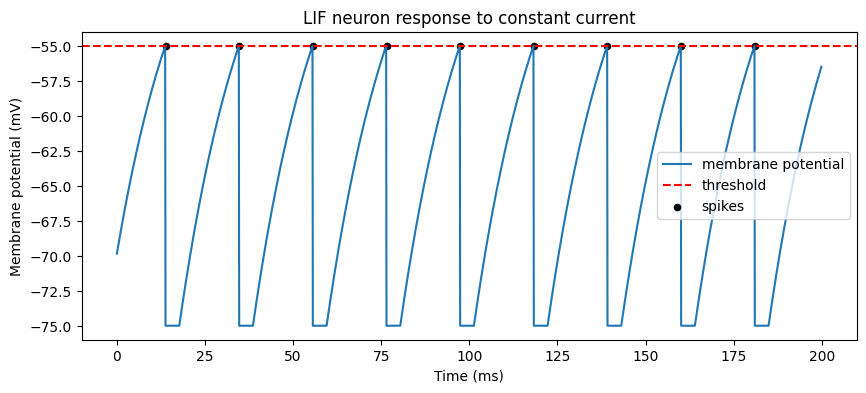

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# модель нейрона
@dataclass
class LIFNeuron:
    tau_m: float = 20.0
    v_rest: float = -70.0
    v_thresh: float = -55.0
    v_reset: float = -75.0
    r_m: float = 10.0
    tau_ref: float = 4.0

    def __post_init__(self):
        self.v = self.v_rest
        self.refractory_until = 0
        self.spike_times = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:

        if t < self.refractory_until:
            self.v = self.v_reset
            return False

        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt

        if self.v >= self.v_thresh:
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)
            return True

        return False


# симуляция
dt = 0.1
T = 200
time = np.arange(0, T, dt)

neuron = LIFNeuron()

I = 3.0  # постоянный ток

v_trace = []

for t in time:
    neuron.step(I, dt, t)
    v_trace.append(neuron.v)


# график
plt.figure(figsize=(10,4))
plt.plot(time, v_trace, label="membrane potential")
plt.axhline(neuron.v_thresh, linestyle="--", color="r", label="threshold")

# отметки спайков
plt.scatter(neuron.spike_times, [neuron.v_thresh]*len(neuron.spike_times),
            color="black", s=20, label="spikes")

plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("LIF neuron response to constant current")
plt.legend()
plt.show()

# 2.4 Современные тенденции и вызовы в ИИ

Вариант 2. Генерация текста
Используйте открытую LLM с Hugging Face для генерации текста по заданному промпту. Создайте функцию, которая принимает начало текста и генерирует его продолжение. Протестируйте на разных стилях: новостной заголовок, начало рассказа, вопрос.

In [6]:
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")

def generate_text(prompt, max_new_tokens=80):
    result = generator(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.9,
        top_k=50
    )
    return result[0]["generated_text"]


prompts = {
    "News headline": "Breaking news:",
    "Story beginning": "Once upon a time in a small village",
    "Question": "Why do humans dream?"
}


for style, prompt in prompts.items():
    print(f"\n===== {style} =====")
    print(f"Prompt: {prompt}\n")
    
    generated = generate_text(prompt)
    print(generated)
    
    print("\n" + "="*60)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7279.22it/s]
Passing `generation_config` together with generation-related arguments=({'top_k', 'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



===== News headline =====
Prompt: Breaking news:



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Breaking news: Russia warns it may be ready for invasion if Trump's 'North Korea' speech is not released

Russia's Foreign Ministry spokesman Maria Zakharova said Moscow thought Trump's speech could cause a panic in the United States and put pressure on U.S. forces to respond.

"But they are not prepared to put pressure as we speak because that's the situation at the moment," she


===== Story beginning =====
Prompt: Once upon a time in a small village



Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Once upon a time in a small village, two or three people can sit and watch television together in the living room. For the first time, the people who were told they could still watch from outside do their first thing in the morning, and then they have to leave.

They then go upstairs to sleep, when their neighbor is present. This happens at this time in the evening during the night. It is not uncommon for people


===== Question =====
Prompt: Why do humans dream?

Why do humans dream? Are they conscious, does this mean they can dream? And what is dreaming about?

Mankind uses imagination to find solutions to the many problems of everyday existence. It is said that the first person we see, when we feel that an event is happening for the first time, is the person we would like to be with the next day. There is no real connection between what we experience and



# 2.5 Нейросетевые системы в продакшене

Вариант 2. Создание API для модели на FastAPI
Создайте простое FastAPI-приложение, которое загружает предобученную модель (например, из sklearn) и предоставляет эндпоинт /predict для получения предсказаний. Добавьте валидацию входных данных. Запустите сервер локально и протестируйте с помощью requests.

In [12]:
!uvicorn app:app --reload

"uvicorn" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [1]:
import requests

url = "http://127.0.0.1:8000/predict"

data = {
    "sepal_length": 5.1,
    "sepal_width": 3.5,
    "petal_length": 1.4,
    "petal_width": 0.2
}

response = requests.post(url, json=data)

print(response.json())

{'prediction': 0}
